In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Dataset overview

In [4]:
# Shape
print("Shape:", df.shape)

# Column names and data types
print("\nData Types:\n", df.dtypes)

# Missing values
print("\nMissing Values:\n", df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:")
df.describe()

Shape: (7043, 21)

Data Types:
 customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing Values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract          

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
# changing total charges datatype
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors ='coerce')

In [6]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [7]:

# Check how many NaN values were created
print("TotalCharges nulls after conversion:", df['TotalCharges'].isnull().sum())

TotalCharges nulls after conversion: 11


In [8]:
# Drop the 11 rows with NaN in TotalCharges
df = df.dropna(subset=['TotalCharges'])



In [9]:
# Check Churn unique values
print("\nChurn values:", df['Churn'].unique())


Churn values: <StringArray>
['No', 'Yes']
Length: 2, dtype: str


In [10]:
# Check SeniorCitizen unique values  
print("SeniorCitizen values:", df['SeniorCitizen'].unique())

SeniorCitizen values: [0 1]


In [11]:
# Check for duplicates
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [12]:

# Confirm shape after cleaning
print("New shape:", df.shape)

New shape: (7032, 21)


## EDA Churn  overview

In [13]:
#churn distribution
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print("Churn Counts:")
print(churn_counts)
print("\nChurn Percentage:")
print(churn_pct.round(2))


Churn Counts:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


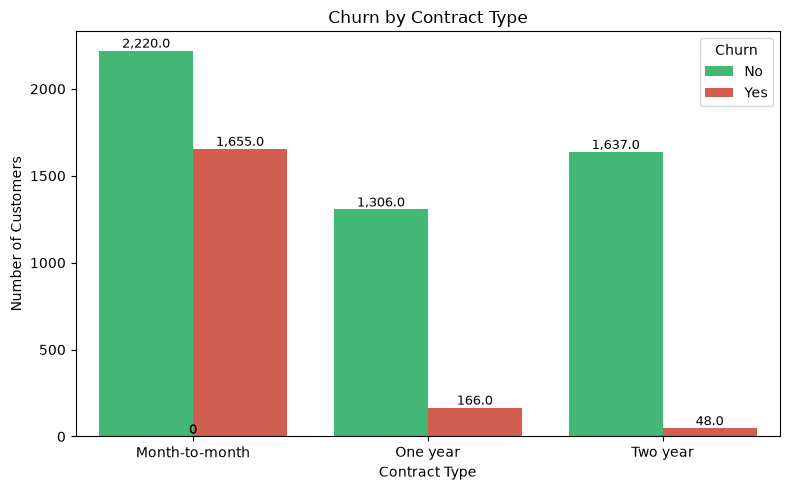

In [14]:
# Churn by Contract Type
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Contract', hue='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

In [15]:
# Churn rate per contract type
print(pd.crosstab(df['Contract'], df['Churn'], normalize='index').round(4) * 100)

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.72  11.28
Two year        97.15   2.85


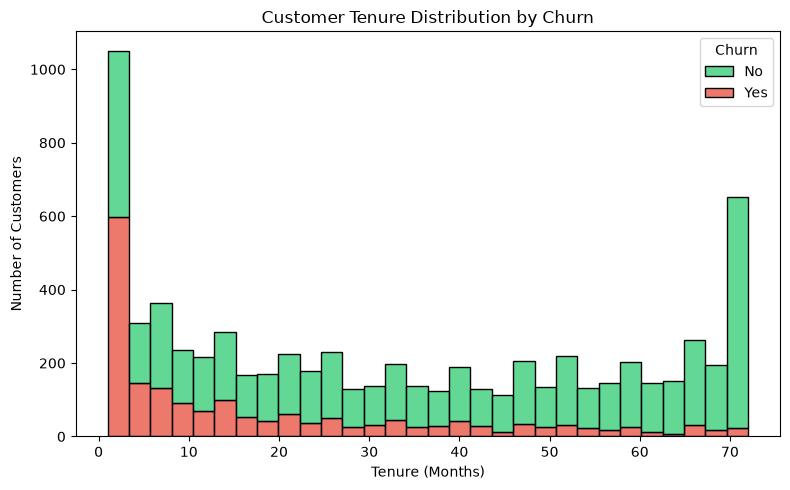

In [16]:
# Tenure distribution by churn
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', palette=['#2ecc71', '#e74c3c'], bins=30)
plt.title('Customer Tenure Distribution by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

In [17]:
# Average tenure by churn status
print(df.groupby('Churn')['tenure'].mean().round(1))


Churn
No     37.7
Yes    18.0
Name: tenure, dtype: float64


C:\Users\Yvvone\AppData\Local\Temp\ipykernel_11056\2985424868.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['#2ecc71', '#e74c3c'])


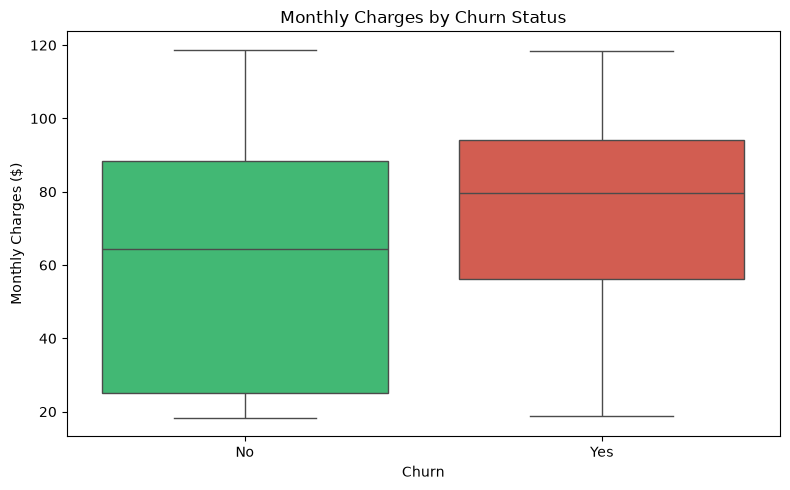

In [18]:
# Monthly Charges distribution by churn
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette=['#2ecc71', '#e74c3c'])
plt.title('Monthly Charges by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.show()

In [19]:
# Average monthly charges by churn
print(df.groupby('Churn')['MonthlyCharges'].mean().round(2))

Churn
No     61.31
Yes    74.44
Name: MonthlyCharges, dtype: float64


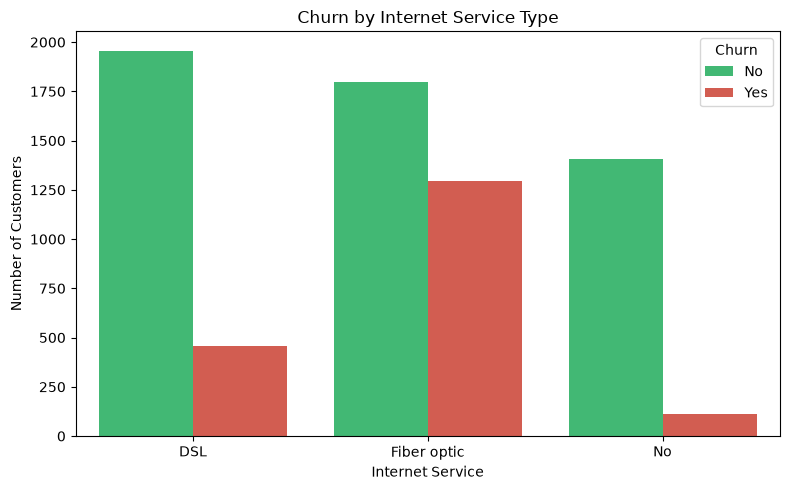

In [20]:
# Churn by Internet Service
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='InternetService', hue='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Churn by Internet Service Type')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

In [21]:
# Churn rate per internet service type
print(pd.crosstab(df['InternetService'], df['Churn'], normalize='index').round(4) * 100)

Churn               No    Yes
InternetService              
DSL              81.00  19.00
Fiber optic      58.11  41.89
No               92.57   7.43


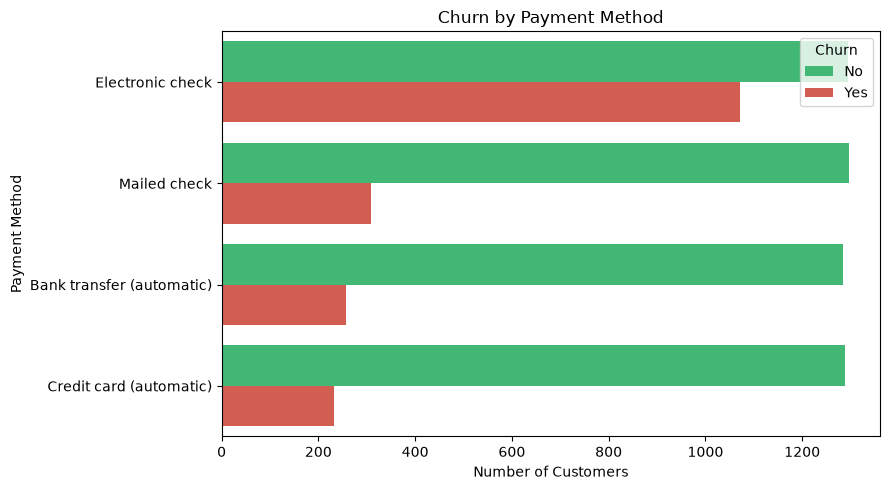

In [22]:
# Churn by Payment Method
plt.figure(figsize=(9, 5))
ax = sns.countplot(data=df, y='PaymentMethod', hue='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Churn by Payment Method')
plt.xlabel('Number of Customers')
plt.ylabel('Payment Method')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

In [23]:
# Churn rate per payment method
print(pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index').round(4) * 100)

Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.27  16.73
Credit card (automatic)    84.75  15.25
Electronic check           54.71  45.29
Mailed check               80.80  19.20


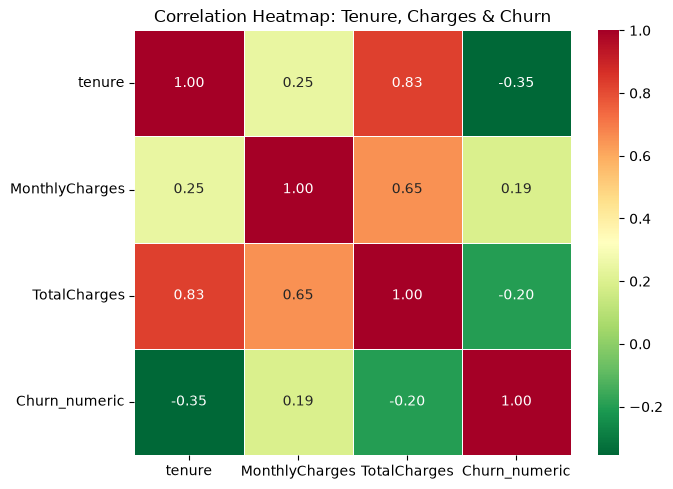

Churn_numeric     1.000000
MonthlyCharges    0.192858
TotalCharges     -0.199484
tenure           -0.354049
Name: Churn_numeric, dtype: float64


In [25]:
# Create a numeric version of Churn for correlation
df['Churn_numeric'] = df['Churn'].map({'No': 0, 'Yes': 1})

# Correlation heatmap
plt.figure(figsize=(7, 5))
corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_numeric']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn_r', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Tenure, Charges & Churn')
plt.tight_layout()
plt.show()

print(corr_matrix['Churn_numeric'].sort_values(ascending=False))

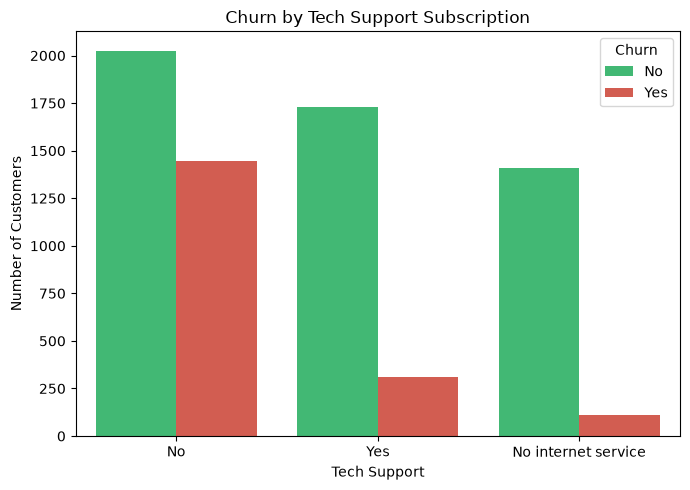

Churn                   No    Yes
TechSupport                      
No                   58.35  41.65
No internet service  92.57   7.43
Yes                  84.80  15.20


In [26]:
# Churn by Tech Support
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='TechSupport', hue='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Churn by Tech Support Subscription')
plt.xlabel('Tech Support')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

print(pd.crosstab(df['TechSupport'], df['Churn'], normalize='index').round(4) * 100)

In [27]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_numeric
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1
